# Demo: SlowBurn 🐢🔥
## Cost-Sustainable Concurrent Execution for Long-Horizon LLM Agents

**Author**: Abhishek Divekar

---

### Background

Long-horizon LLM agents, like autonomous coding assistants and deep research pipelines, 
make dozens to hundreds of API calls per rollout. This makes cost control a practical necessity, especially for academic researchers.

Existing tools either **passively** monitor costs without enforcing budgets, or they hard-terminate the agent when the budget runs out, losing all accumulated progress. 

SlowBurn takes a different approach: when the budget is exhausted, the agent *pauses* via backpressure and resumes when the rate-limit window refills.

No context loss, no termination.

### Contributions
**SlowBurn addresses two emerging topics in the ML community:**
1. Efficient scalable systems and;
2. Practical infrastructure for agentic AI.

### This notebook
This notebook demonstrates SlowBurn end-to-end:

1. **Quick start** — two-line LLM setup with `create_llm()`
2. **Vision support** — send images to the LLM
3. **Global config** — `temp_config()` for environment-specific defaults
4. **Research agent** — a real ReAct agent with web search and file writing, running under a dollar budget
5. **Cost report** — Markdown and LaTeX tables from the agent run

## Architecture

![SlowBurn Architecture](../images/architecture.png)

In [4]:
import os, sys, time
from pathlib import Path
from dotenv import load_dotenv

# Load API keys
load_dotenv(Path("../.env"))

if os.getenv("OPENROUTER_API_KEY"):
    API_KEY = os.getenv("OPENROUTER_API_KEY")
    FAST_MODEL = "openrouter/google/gemini-3.1-flash-lite-preview"  # Supports vision
elif os.getenv("OPENAI_API_KEY", ""):
    API_KEY = os.getenv("OPENAI_API_KEY", "")
    FAST_MODEL = "gpt-4o-mini"
else:
    raise RuntimeError("No key set! Make sure you cloned .env.example into a .env file")

# Add src/ to path so imports work from the notebook
sys.path.insert(0, str(Path("../src").resolve()))

print(f"Fast model:  {FAST_MODEL}")
print(f"API key:     {'Loaded' if API_KEY else 'MISSING'}")

Fast model:  openrouter/google/gemini-3.1-flash-lite-preview
API key:     Loaded


---
## 1. Quick Start: LLM Setup

In [2]:
from slowburn import create_llm

llm = create_llm(
    model=FAST_MODEL,
    api_key=API_KEY,
    budget_usd=10,  # 10 cents per minute
    window="minutely",
    max_tokens=600,
    temperature=0.3,
)

example_prompt = "Explain what backpressure means in distributed systems, in two sentences."
result = llm.call_llm(example_prompt).result(timeout=30.0)

print(f"Question: {example_prompt}")
print(f"Ans: \n{result}")

reporter = llm.get_reporter().result(timeout=5.0)
print(f"\nCost: ${reporter.total_cost():.6f} ({reporter.total_cost()*1e6} microdollars)")

Question: Explain what backpressure means in distributed systems, in two sentences.
Ans: 
In distributed systems, backpressure refers to the phenomenon where a system's output or processing rate is slowed down or blocked due to a bottleneck or congestion in the system, often caused by an overload of incoming requests or data. This can lead to a cascading effect, where the system's performance and responsiveness degrade, and the backlog of work builds up, causing further delays and inefficiencies.

Cost: $0.000004 (4.0 microdollars)


### Batch calls (concurrent)

All three prompts execute concurrently on the asyncio event loop.

In [3]:
example_prompts = [
    "Name one advantage of rate limiting in APIs.",
    "Name one advantage of circuit breakers in microservices.",
    "Name one advantage of exponential backoff in retries.",
    "Name one advantage of connection pooling in databases.",
    "Name one advantage of load balancing across servers.",
    "Name one advantage of caching in web applications.",
    "Name one advantage of message queues in distributed systems.",
    "Name one advantage of health checks in container orchestration.",
    "Name one advantage of idempotency in API design.",
    "Name one advantage of sharding in large databases.",
    "Name one advantage of blue-green deployments.",
    "Name one advantage of write-ahead logging in databases.",
    "Name one advantage of token buckets for rate limiting.",
    "Name one advantage of eventual consistency in distributed systems.",
    "Name one advantage of graceful degradation in web services.",
    "Name one advantage of observability over traditional monitoring.",
    "Name one advantage of immutable infrastructure.",
    "Name one advantage of service meshes in Kubernetes.",
    "Name one advantage of dead letter queues in messaging.",
    "Name one advantage of feature flags in continuous deployment.",
    "Name one advantage of bulkhead isolation in microservices.",
    "Name one advantage of content-addressable storage.",
    "Name one advantage of consensus algorithms like Raft.",
    "Name one advantage of backpressure in stream processing.",
    "Name one advantage of read replicas in database architectures.",
    "Name one advantage of canary releases in production deployments.",
    "Name one advantage of structured logging over plain text logs.",
    "Name one advantage of CRDTs in distributed data structures.",
    "Name one advantage of event sourcing over CRUD.",
    "Name one advantage of sidecar proxies in service architectures.",
    "Name one advantage of consistent hashing in distributed caches.",
    "Name one advantage of lease-based locking in distributed systems.",
    "Name one advantage of column-oriented storage for analytics.",
    "Name one advantage of saga patterns for distributed transactions.",
    "Name one advantage of bloom filters in large-scale lookups.",
    "Name one advantage of priority queues in task scheduling.",
    "Name one advantage of copy-on-write semantics in data structures.",
    "Name one advantage of zero-downtime migrations in databases.",
    "Name one advantage of chaos engineering in production systems.",
    "Name one advantage of shadow traffic for testing new services.",
    "Name one advantage of vector clocks in conflict resolution.",
    "Name one advantage of gossip protocols in cluster membership.",
    "Name one advantage of coroutines over threads for I/O concurrency.",
    "Name one advantage of append-only data structures in databases.",
    "Name one advantage of request coalescing under high load.",
    "Name one advantage of multi-tenancy in SaaS architectures.",
    "Name one advantage of adaptive concurrency limits.",
    "Name one advantage of pipelining in network protocols.",
    "Name one advantage of predicate pushdown in query engines.",
    "Name one advantage of tombstones in eventually consistent stores.",
]
start = time.time()
print(f"Making {len(example_prompts)} concurrent calls...")
results = llm.call_llm_batch(example_prompts).result(timeout=120.0)
elapsed = time.time() - start

for p, r in zip(example_prompts, results):
    print("=" * 80)
    print(f"Prompt: {p.strip()}\n")
    print(f"Response:\n{r.strip()}")
print("=" * 80)
print(f"\n{len(example_prompts)} concurrent calls in {elapsed:.1f}s")
print(f"\nCost: ${reporter.total_cost():.6f} ({reporter.total_cost()*1e6} microdollars)")

# llm.stop()

Making 50 concurrent calls...


Usage (47) exceeds requested amount (33) for limit 'input_tokens'. This may indicate incorrect usage tracking or unexpected token consumption. Excess usage will be constrained by limit capacity (1000000).
Usage (44) exceeds requested amount (30) for limit 'input_tokens'. This may indicate incorrect usage tracking or unexpected token consumption. Excess usage will be constrained by limit capacity (1000000).
Usage (48) exceeds requested amount (35) for limit 'input_tokens'. This may indicate incorrect usage tracking or unexpected token consumption. Excess usage will be constrained by limit capacity (1000000).
Usage (47) exceeds requested amount (33) for limit 'input_tokens'. This may indicate incorrect usage tracking or unexpected token consumption. Excess usage will be constrained by limit capacity (1000000).
Usage (45) exceeds requested amount (31) for limit 'input_tokens'. This may indicate incorrect usage tracking or unexpected token consumption. Excess usage will be constrained by l

Prompt: Name one advantage of rate limiting in APIs.

Response:
One advantage of rate limiting in APIs is that it helps prevent abuse and denial-of-service (DoS) attacks. By limiting the number of requests a user or IP address can make within a certain time frame, rate limiting prevents malicious users from overwhelming the API with requests, thereby protecting the API and its underlying resources from being overwhelmed and potentially crashing.
Prompt: Name one advantage of circuit breakers in microservices.

Response:
One advantage of circuit breakers in microservices is that they allow for **fault tolerance and resilience**. A circuit breaker is a design pattern that detects when a service is not responding or is experiencing high latency, and it prevents the application from sending further requests to that service until it is available again. This prevents cascading failures, where a single failing service causes a chain reaction of failures in other services that depend on it.

B

## Backpressure slows down the calls until we get enough budget

In [5]:
llm = create_llm(
    model=FAST_MODEL,
    api_key=API_KEY,
    budget_usd=0.1,  # 10 cents per minute
    window="minutely",
    max_tokens=600,
    temperature=0.3,
)

for i in range(1, 3+1):
    start = time.time()
    print(f"Round#{i}: Making {len(example_prompts)} concurrent calls...")
    results = llm.call_llm_batch(example_prompts, verbosity=2).result(timeout=120.0)
    elapsed = time.time() - start
    print(f"{len(example_prompts)} concurrent calls in {elapsed:.1f}s")
    reporter = llm.get_reporter().result(timeout=5.0)
    print(f"Cost: ${reporter.total_cost():.6f} ({reporter.total_cost()*1e6} microdollars)")
    print("=" * 80)

llm.stop()

Round#1: Making 50 concurrent calls...


openrouter/google/gemini-3.1-flash-lite-preview: 59row [00:05, 10.86row/s]                          


50 concurrent calls in 5.4s
Cost: $0.007299 (7299.0 microdollars)
Round#2: Making 50 concurrent calls...


openrouter/google/gemini-3.1-flash-lite-preview: 59row [00:05, 10.07row/s]                          


50 concurrent calls in 5.9s
Cost: $0.014760 (14760.0 microdollars)
Round#3: Making 50 concurrent calls...


openrouter/google/gemini-3.1-flash-lite-preview: 59row [00:59,  1.01s/row]                          

50 concurrent calls in 59.8s
Cost: $0.022014 (22014.0 microdollars)


### The downstream is not slow! We can make the exact same calls at full speed

In [6]:
llm2 = create_llm(
    model=FAST_MODEL,
    api_key=API_KEY,
    budget_usd=0.1,  # 10 cents per minute
    window="minutely",
    max_tokens=600,
    temperature=0.3,
)
start = time.time()
results = llm2.call_llm_batch(example_prompts).result(timeout=120.0)
elapsed = time.time() - start
print(f"{len(example_prompts)} concurrent calls in {elapsed:.1f}s")
llm2.stop()

50 concurrent calls in 6.3s


## Warn (or fail-fast) on budget overflow for 1 LLM call

In [3]:
llm3 = create_llm(
    model=FAST_MODEL,
    api_key=API_KEY,
    budget_usd=0.0001,  # 0.01 cents per minute
    window="minutely",
    max_tokens=600,
    temperature=0.3,
    on_budget_overflow="warn", ## Or: "error" to fail-fast
)
results = llm3.call_llm(example_prompt).result(timeout=120.0)
llm3.stop()

[openrouter/google/gemini-3.1-flash-lite-preview] Budget overflow: A single call_llm() call to openrouter/google/gemini-3.1-flash-lite-preview is estimated to cost $0.000909 (~36 input + 600 output tokens), which exceeds your budget_usd per window. Fix by: (1) increasing the budget while creating the LLM, (2) reducing max_tokens (currently 600), or (3) using a more budget-friendly model.
Usage (84) exceeds requested amount (1) for limit 'cost_microdollars'. This may indicate incorrect usage tracking or unexpected token consumption. Excess usage will be constrained by limit capacity (100).


In [5]:
example_prompt

'Explain what backpressure means in distributed systems, in two sentences.'

---
## 2. Vision: Send Images to the LLM

10 test images available


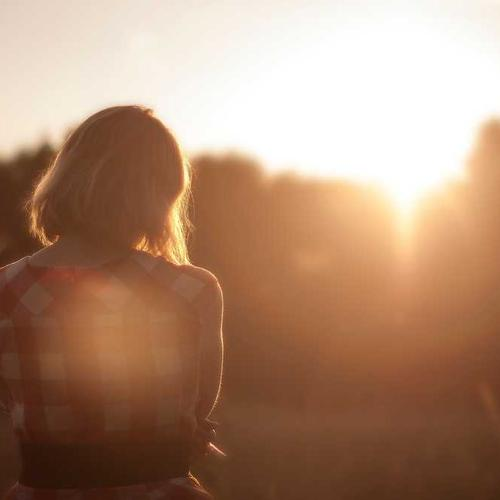


test_image_1.jpg: A person with short hair, seen from behind, stands in a field during a warm, golden sunset that creates a soft, hazy glow around them.


In [7]:
from IPython.display import display, Image

llm = create_llm(
    model=FAST_MODEL,
    api_key=API_KEY,
    budget_usd=0.1,  # 10 cents per minute
    window="minutely",
    max_tokens=600,
    temperature=0.3,
)

image_dir = Path("../tests/fixtures/images")
test_images = sorted(image_dir.glob("test_image_*.jpg"))
print(f"{len(test_images)} test images available")

desc = llm.call_llm(
    prompt="Describe this image in one detailed sentence.",
    images=[test_images[0]],  # gravel road
).result(timeout=60.0)
print(f"\n{test_images[0].name}: {desc}")
display(Image(test_images[0]))

llm.stop()  # done with quick-start worker

---
## 3. Global Config: `temp_config()` for Environment-Specific Defaults

In [14]:
from slowburn import slowburn_config, temp_config

cfg = slowburn_config.defaults
print("Current defaults:")
print(f"  temperature:       {cfg.temperature}")
print(f"  max_tokens:        {cfg.max_tokens}")
print(f"  budget_usd:        ${cfg.budget_usd}")
print(f"  chars_per_token:   {cfg.chars_per_token}")
print(f"  safety_multiplier: {cfg.token_safety_multiplier}")

print()

# temp_config scopes overrides — everything reverts on exit
with temp_config(temperature=0.0, max_tokens=50, budget_usd=0.10):
    print(f"Inside temp_config:  temperature={slowburn_config.defaults.temperature}, "
          f"max_tokens={slowburn_config.defaults.max_tokens}, "
          f"budget_usd=${slowburn_config.defaults.budget_usd}")

print(f"After temp_config:   temperature={cfg.temperature}, "
      f"max_tokens={cfg.max_tokens}, "
      f"budget_usd=${cfg.budget_usd}  (restored)")

Current defaults:
  temperature:       0.7
  max_tokens:        1000
  budget_usd:        $5.0
  chars_per_token:   3.0
  safety_multiplier: 5.0

Inside temp_config:  temperature=0.0, max_tokens=50, budget_usd=$0.1
After temp_config:   temperature=0.7, max_tokens=1000, budget_usd=$5.0  (restored)


---
## 4. Research Agent Under Dollar Budget

This runs the **actual `demo_native_research_agent`** — a ReAct agent that:
- Searches the web with DuckDuckGo
- Takes notes by writing files to a sandboxed workspace
- Synthesizes a research report

Every LLM call is cost-tracked. When the budget is exhausted, SlowBurn blocks (backpressure) rather than crashing.

In [1]:
import os, sys, time
from pathlib import Path
# Add src/ to path so imports work from the notebook
sys.path.insert(0, str(Path("../src").resolve()))
from pathlib import Path
from dotenv import load_dotenv

# Load API keys
load_dotenv(Path("../.env"))

if os.getenv("OPENROUTER_API_KEY"):
    API_KEY = os.getenv("OPENROUTER_API_KEY")
    AGENT_MODEL = "openrouter/z-ai/glm-4.5-air"  # Good at tool calling
elif os.getenv("OPENAI_API_KEY", ""):
    API_KEY = os.getenv("OPENAI_API_KEY", "")
    AGENT_MODEL = "gpt-4o"
else:
    raise RuntimeError("No key set! Make sure you cloned .env.example into a .env file")

print(f"Fast model:  {AGENT_MODEL}")
print(f"API key:     {'Loaded' if API_KEY else 'MISSING'}")

Fast model:  openrouter/z-ai/glm-4.5-air
API key:     Loaded


In [2]:
from slowburn import create_llm
from datetime import datetime

# Import the shared agent loop and tools
sys.path.insert(0, str(Path(".").resolve()))
from lib.agent_loop import run_agent
from lib.tools import TOOL_SCHEMAS, execute_tool_call

BUDGET_USD = 0.25e-2  # 0.25 cent per 30 seconds
BUDGET_WINDOW_SECONDS = 30
MAX_STEPS = 20
OUTPUT_FILE = "fusion_approaches.md"

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
runs_dir = Path(f"runs/native_research_agent/{timestamp}")
runs_dir.mkdir(parents=True, exist_ok=True)


# Create a SlowBurnLLM worker — the agent uses this for every LLM call
agent_llm = create_llm(
    model=AGENT_MODEL,
    api_key=API_KEY,
    budget_usd=BUDGET_USD,
    window=BUDGET_WINDOW_SECONDS,
    max_tokens=600,
    temperature=0.95,
    backpressure_notify="warn",  # log when budget blocks
)

def tool_executor(name, args):
    return execute_tool_call(name, args, workspace=runs_dir)

print(f"Agent model: {AGENT_MODEL}")
print(f"Budget:      ${BUDGET_USD} per {BUDGET_WINDOW_SECONDS}s window")
print(f"Max steps:   {MAX_STEPS}")
print(f"Output file: {OUTPUT_FILE}")
print(f"Workspace:   {runs_dir}")

Agent model: openrouter/z-ai/glm-4.5-air
Budget:      $0.0025 per 30s window
Max steps:   20
Output file: fusion_approaches.md
Workspace:   runs/native_research_agent/20260315_000431


In [3]:
RESEARCH_TASK = (
    "Compare the major approaches for achieving nuclear fusion energy: "
    "tokamak (ITER, Commonwealth Fusion SPARC), stellarator (Wendelstein 7-X), "
    "inertial confinement (NIF), and any private ventures (Helion, TAE). "
    "Search for each project's latest milestone, their projected timeline to "
    "net energy gain, and total funding to date. "
    "Then search for what engineering challenges remain unsolved for each. "
    "Write a structured comparison to 'fusion_approaches.md' with sources."
)

SYSTEM_PROMPT = """\
You are a thorough research agent. You have access to these tools:
- search_web: Search the web with DuckDuckGo to find real information
- write_file: Save your research notes and reports to files
- read_file: Read files you've previously written
- list_dir: See what files exist in your workspace

For the research task:
1. Use search_web 2-3 times with different queries to gather information
2. Use write_file to save a structured report with real sources and URLs
3. Be specific: cite actual numbers, paper names, and URLs from search results

IMPORTANT: You MUST use search_web to find real data. Do NOT make up facts."""


In [4]:
print(f"Task: {RESEARCH_TASK}...")
print("\nRunning agent...\n")

start = time.time()
result = run_agent(
    llm=agent_llm,
    task=RESEARCH_TASK,
    tools=TOOL_SCHEMAS,
    tool_executor=tool_executor,
    system_prompt=SYSTEM_PROMPT,
    max_steps=MAX_STEPS,
    verbose=True,
    output_file=OUTPUT_FILE,
    log_dir=runs_dir / "fusion_approaches",
    workspace=runs_dir,
)
elapsed = time.time() - start

print(f"\nAgent finished in {elapsed:.1f}s")
print(f"Steps: {result['steps']}, Tool calls: {result['tool_calls']}")

reporter = agent_llm.get_reporter().result(timeout=5.0)
print(f"Cost: ${reporter.total_cost():.6f}")

Task: Compare the major approaches for achieving nuclear fusion energy: tokamak (ITER, Commonwealth Fusion SPARC), stellarator (Wendelstein 7-X), inertial confinement (NIF), and any private ventures (Helion, TAE). Search for each project's latest milestone, their projected timeline to net energy gain, and total funding to date. Then search for what engineering challenges remain unsolved for each. Write a structured comparison to 'fusion_approaches.md' with sources....

Running agent...


    ── Step 1/20 ──
    [loop] Sending initial task to LLM
    [llm]  tool call: search_web({"query": "tokamak fusion ITER SPARC Commonwealth Fusion latest milestones funding timeline"})
    [loop] Executed search_web → 1951 chars returned
    [llm]  
I'll help you create a comprehensive comparison of major fusion energy approaches. Let me start by gathering information on each approach and their key projects.

    [cost] step $0.000207 | total $0.000207 | 1 LLM calls | 1 tool calls

    ── Step 2/20 ─

[openrouter/z-ai/glm-4.5-air] Backpressure: blocked 8.4s waiting for budget/rate capacity (estimated $0.000749, ~1846 input + 600 output tokens)


    [llm]  tool call: append_findings({"content": "### Stellarator Approach\n\n**Wendelstein 7-X**\n- World's largest stellarator facility located in Germany\n- Recently achieved a breakthrough by generating high-energy helium-3 ions for the first time using radio waves\n- Germany's stellarator fusion reactor projected to deliver power by 2031\n- Offers inherent stability advantages and is leading candidate for sustained fusion energy\n\n### Private Fusion Ventures\n\n**Proxima Fusion**\n- Secured €130M in Series A funding, joining ranks of well-funded nuclear startups\n- Develops its own stellarator design called \"Stellaris\"\n- Positioned with proximity to Germany's Wendelstein 7-X, the world's largest stellarator\n- Part of Germany's €2b plan for commercial fusion plants by 2030\n\n### Engineering Challenges and Commercial Outlook\n- Stellarators like Wendelstein 7-X promise 24/7 clean energy without disruptions\n- Advancement in magnetic confinement fusion continues to eliminate p

[openrouter/z-ai/glm-4.5-air] Backpressure: blocked 5.0s waiting for budget/rate capacity (estimated $0.000820, ~2392 input + 600 output tokens)


    [llm]  tool call: search_web({"query": "ITER fusion reactor funding budget 2024 2025 latest cost"})
    [loop] Executed search_web → 1967 chars returned
    [llm]  

    [cost] step $0.000358 | total $0.002753 | 7 LLM calls | 7 tool calls

    ── Step 8/20 ──
    [loop] Including last turn (2 messages) as context
    [loop] Reading workspace: 1 file(s) included as context
    [loop] Instructing LLM: append findings to 'fusion_approaches.md'
    [loop] Calling LLM...


...

    [llm]  tool call: search_web({"query": "tokamak engineering challenges magnetic confinement fusion 2024-2025 plasma stability disruptions"})
    [loop] Executed search_web → 1686 chars returned
    [llm]  

    [cost] step $0.000541 | total $0.008398 | 17 LLM calls | 17 tool calls

    ── Step 18/20 ──
    [loop] Including last turn (2 messages) as context
    [loop] Reading workspace: 1 file(s) included as context
    [loop] Instructing LLM: append findings to 'fusion_approaches.md'
    [loop] Calling LLM...
    [llm]  tool call: append_findings({"content": "### Engineering Challenges - Latest Developments (2024-2025)\n\n**Tokamak-Specific Engineering Challenges**\n- **Magnetic Field Evolution Constraints**: Recent research indicates that plasma duration", "Source": "www.davidmaiolo.com/2025/02/", "Requirements**": "Fusion energy requires extremely strong magnetic fields to confine and control hydrogen fuel plasma", "Advancement**": "The company is amidst rapid scale-up to commerc

[openrouter/z-ai/glm-4.5-air] Backpressure: blocked 8.5s waiting for budget/rate capacity (estimated $0.000919, ~3152 input + 600 output tokens)


    [llm]  tool call: search_web({"query": "Wendelstein 7-X latest engineering challenges 2024 stellarator problems"})
    [loop] Executed search_web → 2367 chars returned
    [llm]  

    [cost] step $0.000500 | total $0.009686 | 19 LLM calls | 19 tool calls

    ── Step 20/20 ──
    [loop] Including last turn (2 messages) as context
    [loop] Reading workspace: 1 file(s) included as context
    [loop] Instructing LLM: append findings to 'fusion_approaches.md'
    [loop] Calling LLM...


[openrouter/z-ai/glm-4.5-air] Backpressure: blocked 2.0s waiting for budget/rate capacity (estimated $0.001028, ~3992 input + 600 output tokens)


    [llm]  tool call: append_findings({"content": "### Stellarator Approach - Latest Developments (2024-2025)\n\n**Wendelstein 7-X Updates**\n- **Latest Milestones**: Completed three successful experimental campaigns in 2024/25 timeframe with extensive systems upgrades\n- **Technical Upgrades**: Installation of new heating systems and a steady-state pellet injector\n- **Record Achievement**: Set a new world record in the triple product", "Achievement**": "Generated high-energy helium-3 ions for the first time using radio waves\n\n### Engineering Challenges - Stellarator Specific (2024-2025)\n\n**Wendelstein 7-X Current Technical Hurdles**\n- **Heat Flux Management**: Handling continuous high heat fluxes on plasma-facing components remains a significant challenge\n- **Material Development**: Need for robust", "Challenges**": "Difficulty scaling the stellarator design from experimental size to practical reactor dimensions\n- **Engineering Precision**: Success relies on extremely precise 

### Agent's output

In [5]:
import json
# Show the research report the agent wrote
report_path = runs_dir / "fusion_approaches.md"
if not report_path.exists():
    raise ValueError(f'No report at "{report_path}"!')
from IPython.display import Markdown, display
display(Markdown(report_path.read_text()))

## Major Fusion Energy Approaches - Initial Findings

### Tokamak Approach

**ITER (International Thermonuclear Experimental Reactor)**
- Currently the largest and most internationally funded fusion project
- Involves 35 nations collaborating
- Despite its scale and funding, faces inherent inefficiencies due to multinational coordination
- Known as the "Great Hot" fusion project in some circles

**Commonwealth Fusion Systems SPARC**
- Commercial fusion company proposing tokamak construction
- Located in Devens, Massachusetts
- Using tokamak design (donut-shaped machine) as the most scientifically proven way to recreate sun's power
- Part of the push toward commercial fusion energy
- Funding history resembles that of OpenAI in terms of trajectory (though CFS is younger)

### Funding and Commercialization Trends
- Several commercial fusion companies have proposed tokamak construction in recent years
- Private funding for fusion projects is growing, with patterns similar to other high-tech ventures
- Both ITER and SPARC largely use the same tokamak physics knowledge base
- Timeline differences exist between publicly funded projects and private ventures

### Stellarator Approach

**Wendelstein 7-X**
- World's largest stellarator facility located in Germany
- Recently achieved a breakthrough by generating high-energy helium-3 ions for the first time using radio waves
- Germany's stellarator fusion reactor projected to deliver power by 2031
- Offers inherent stability advantages and is leading candidate for sustained fusion energy

### Private Fusion Ventures

**Proxima Fusion**
- Secured €130M in Series A funding, joining ranks of well-funded nuclear startups
- Develops its own stellarator design called "Stellaris"
- Positioned with proximity to Germany's Wendelstein 7-X, the world's largest stellarator
- Part of Germany's €2b plan for commercial fusion plants by 2030

### Engineering Challenges and Commercial Outlook
- Stellarators like Wendelstein 7-X promise 24/7 clean energy without disruptions
- Advancement in magnetic confinement fusion continues to eliminate plasma disruptions
- Private funding patterns for fusion companies resemble other high-tech venture capital trajectories
- Commercialization timelines vary between publicly funded projects (longer) and private ventures (shorter)

### Inertial Confinement Fusion

**National Ignition Facility (NIF)**
- **Latest Milestones**: Achieved record 8.6 megajoules output in recent experiments, with prior shots yielding 5.2 megajoules. The eighth ignition experiment on April 7, 2025 set new records for net-positive fusion energy gains.
- **Funding Status**: Pursuing funding for Enhanced Yield Capability (EYC) project to increase laser power from 2.2 megajoules to 2.6 megajoules. Operated by Lawrence Livermore National Laboratory under U.S. Department of Energy.
- **Engineering Challenges**: Despite achieving ignition, proving more challenging than first expected, the path to practical fusion energy remains long-term. The facility primarily supports nuclear stockpile stewardship while advancing fusion science.

### Private Fusion Ventures Update

**Proxima Fusion**
- Secured €130M in Series A funding
- Developing "Stellaris" stellarator design
- Positioned near Germany's Wendelstein 7-X facility
- Part of Germany's €2 billion plan for commercial fusion plants by 2030

**Helion & TAE Technologies**
- Additional private fusion companies making strides in commercial fusion development
- Following venture capital funding patterns similar to other high-tech startups
- Aiming for shorter commercialization timelines compared to publicly funded projects

### ITER Updates (Latest Information)
- **Cost Overruns**: ITER has confirmed more delays and around €5 billion in additional costs, bringing the total estimated cost to approximately $28 billion
- **Construction Status**: Recently completed installation of its last magnetic coil - a significant construction milestone
- **Timeline**: Current end goal remains 2025, though delays are acknowledged
- **International Scope**: Involves 35 nations collaborating on the world's largest fusion reactor
- **Latest Development**: In early 2024, China announced the launch of "Fusion Energy Inc," a fusion consortium that aims to build an industrial prototype fusion reactor

### Funding and Commercialization Trends (Updated)
- ITER's $28 billion total cost highlights the immense financial requirements of large-scale fusion projects
- Private fusion companies are following different funding trajectories compared to publicly funded projects like ITER
- Commercial fusion ventures aim for shorter timelines and potentially more cost-effective approaches

### Note: Incomplete Information
The above search focused specifically on ITER updates. Complete information about other fusion approaches (stellarator, inertial confinement, and private ventures) including their latest milestones, funding, timelines, and engineering challenges still needs to be gathered to fulfill the full comparison task.

### Private Fusion Ventures - Helion Energy Update

**Helion Energy**
- **Latest Milestones**: Completed construction of its Polaris reactor prototype at the end of 2024; began operating its 7th-generation Polaris prototype in late 2024
- **Funding Status**: Closed $0.5 billion Series E with additional $1.7 billion commitments tied to specific milestones; raised $425 million in fresh funding, bringing total investment to $1 billion
- **Timeline**: Hopes to demonstrate electricity from fusion from the Polaris reactor as soon as 2025/2026
- **Recent Development**: Announced a significant fusion milestone and is moving closer to commercial deployment (February 2026 announcement)
- **Status**: Based in Everett, Washington, founded in 2013, positioning itself as a leader in private fusion development

### Private Fusion Ventures - TAE Technologies Update

**TAE Technologies**
- **Latest Milestones**: Exceeded fusion reactor performance goals by 250% with significant scientific achievements in their current Norman reactor
- **Funding Status**: Closed $250 million financing round, bringing total funding to $1.2 billion to date; recent capital injection surpassed initial targets for this round
- **Key Investors**: Received investments from long-term partner Google and other strategic backers
- **Technology**: Developing proprietary field-reversed configuration (FRC) approach with hydrogen-boron (p-B11) fuel to create compact, scalable reactors
- **Status**: Based in Foothill Ranch, California, has emerged as a leader in the fusion energy sector and is nearing fusion power breakthrough

### Recent Engineering Advances and Shared Challenges (2024-2025)

**Common Technical Challenges Across Fusion Approaches**
Recent research highlights shared technical challenges between magnetic confinement (tokamak

### Shared Engineering Challenges Across Fusion Approaches (2024-2025)

**Common Technical Challenges**

**Plasma Stability and Control**
- **Tearing Instabilities**: A major challenge where magnetic islands form

### Engineering Challenges - Latest Developments (2024-2025)

**Tokamak-Specific Engineering Challenges**
- **Magnetic Field Evolution Constraints**: Recent research indicates that plasma duration

### Stellarator Approach - Latest Developments (2024-2025)

**Wendelstein 7-X Updates**
- **Latest Milestones**: Completed three successful experimental campaigns in 2024/25 timeframe with extensive systems upgrades
- **Technical Upgrades**: Installation of new heating systems and a steady-state pellet injector
- **Record Achievement**: Set a new world record in the triple product

---
## 5. Cost Report

The `CostReporter` accumulated every LLM call from the agent run.

In [16]:
from IPython.display import Markdown, display

reporter = agent_llm.get_reporter().result(timeout=5.0)

print(f"Total LLM calls: {reporter.num_calls}")
print(f"Total cost:      ${reporter.total_cost():.6f}")
print()

# Markdown table
print(reporter.to_markdown())

Total LLM calls: 20
Total cost:      $0.010509

| Model | Calls | Input Tokens | Output Tokens | Total Tokens | Cost (USD) |
|-------|------:|-------------:|--------------:|-------------:|-----------:|
| openrouter/z-ai/glm-4.5-air | 20 | 39,646 | 7,547 | 47,193 | $0.010509 |
| **Total** | **20** | **39,646** | **7,547** | **47,193** | **$0.010509** |


In [7]:
# Files the agent created
print(f"Files in workspace ({runs_dir}):")
for f in sorted(runs_dir.rglob("*")):
    if f.is_file() and not str(f.name).startswith("."):
        print(f"  {f.relative_to(runs_dir)}: {f.stat().st_size:,} bytes")

# Save cost report to JSON
json_path = reporter.to_json(path=runs_dir / "_cost_report.json")
print(f"\nCost report saved to: {json_path}")

Files in workspace (runs/native_research_agent/20260315_000431):
  fusion_approaches/max_steps_reached.json: 47 bytes
  fusion_approaches/step_01/input.json: 1,265 bytes
  fusion_approaches/step_01/output.json: 304 bytes
  fusion_approaches/step_01/tool_01_call.json: 199 bytes
  fusion_approaches/step_01/tool_01_result.json: 2,112 bytes
  fusion_approaches/step_02/input.json: 4,431 bytes
  fusion_approaches/step_02/output.json: 1,419 bytes
  fusion_approaches/step_02/tool_01_call.json: 1,316 bytes
  fusion_approaches/step_02/tool_01_result.json: 83 bytes
  fusion_approaches/step_03/input.json: 4,617 bytes
  fusion_approaches/step_03/output.json: 285 bytes
  fusion_approaches/step_03/tool_01_call.json: 180 bytes
  fusion_approaches/step_03/tool_01_result.json: 1,874 bytes
  fusion_approaches/step_04/input.json: 5,201 bytes
  fusion_approaches/step_04/output.json: 1,412 bytes
  fusion_approaches/step_04/tool_01_call.json: 1,308 bytes
  fusion_approaches/step_04/tool_01_result.json: 83 by

---

## That's SlowBurn
A real research agent ran under a $0.15 budget,
searched the web, wrote files, and every LLM call was cost-tracked.
If the budget had been exhausted, the agent would have slowed down (backpressure)
rather than crashing.